# **Dog Emotion Recognition Project Using Deep Learning**
## **DSA Internal Project Group 2**

**Group Members:** Cheryl, De Xun, Shaista, Thaddeus, Yamini

## **1. Introduction**
Dogs communicate emotions primarily through facial expressions and body language. Human observation can be subjective, inconsistent, and unsustainable for continuous monitoring.  

**Goal:** Build an automated deep learning system that detects canine emotions (e.g., happy, sad, angry, relaxed) from images to:

- Enhance animal welfare by identifying chronic stress or discomfort early  
- Personalize pet care by providing objective feedback during training or enrichment activities  

##**2. Dataset Understanding**

**Objectives:**  
- Understand dataset structure, classes, image quality, and challenges  
- Identify class imbalance, missing data, or inconsistencies


**Data Understanding Steps:** <br>

1) Load data (data ingestion)
2) Summary statistics of raw data
3) Generate visualisation of raw data (to understand it)

###2.1 Imports

In [9]:
# Import all the essential libraries

from google.colab import files
import os, json, sys
import zipfile
import torch
import torchvision.transforms as T
import PIL
from PIL import Image
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gradio as gr
import plotly.express as px

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import urllib.request

print(f"▶ numpy      {np.__version__}")
print(f"▶ pandas     {pd.__version__}")
print(f"▶ matplotlib {matplotlib.__version__}")
print(f"▶ Pillow     {PIL.__version__}")
print(f"▶ tensorflow {tf.__version__}")
print(f"▶ gradio     {gr.__version__}")


▶ numpy      2.0.2
▶ pandas     2.2.2
▶ matplotlib 3.10.0
▶ Pillow     11.3.0
▶ tensorflow 2.19.0
▶ gradio     5.50.0


###2.2 Unzip the dataset folder

In [ ]:
# Load data from zip file
zip_path = "/content/DogEmotion.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

###2.3 Load CSV file and understand the dataset

In [ ]:
# Load data from zip file

# Check labels.csv file
raw_df = pd.read_csv("/content/DogEmotion/dog_emotion_labels.csv")

# Basic dataset info
raw_df.info()
raw_df.head()
raw_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4000 non-null   int64 
 1   filename    4000 non-null   object
 2   label       4000 non-null   object
dtypes: int64(1), object(2)
memory usage: 93.9+ KB


,Unnamed: 0
count,4000.000000
mean,1999.500000
std,1154.844867
min,0.000000
25%,999.750000
50%,1999.500000
75%,2999.250000
max,3999.000000


In [ ]:
# Check number of unique labels and their occurrences
raw_df['label'].value_counts()

,count
label,
sad,1000
angry,1000
relaxed,1000
happy,1000


##**3. Problem Definition & Scoping**
##Problem Statement:
The core problem addressed by this project is the inability to objectively, consistently, and scalably monitor canine emotional states, leading to missed opportunities for early intervention in animal welfare and personalized care. Human observation of subtle behavioral cues is subjective, prone to error, and unsustainable for continuous (24/7) monitoring or large-scale facility management. The solution is the development of a robust, automated system.

Problem Type: Image classification using deep learning
<br>
<br>
##Real-World Justification:
This solution provides objective data to: Enhance Animal Welfare: Provide an early warning system for chronic stress (Sadness/Anger) in shelter or home environments, prompting timely veterinary or behavioral consultation. Personalize Pet Care: Offer pet owners objective feedback on their dog's state during training or enrichment activities, leading to more effective and humane interaction.
<br>
<br>

##Success Criteria:

- Model achieves high accuracy (e.g., >80%) on validation images

- Correctly identifies stress-related emotions (Sadness/Anger)

- Handles class imbalance

## **4. Data Cleaning**

**Tasks:**

- Remove missing, corrupted, duplicated and irrelavant images

- Normalize labels

- Resize images for model input

###4.1 Check and remove duplicated filenames

In [ ]:
# Remove duplicated filenames (no duplicates anyways)
raw_df.drop_duplicates(subset='filename', inplace=True)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4000 non-null   int64 
 1   filename    4000 non-null   object
 2   label       4000 non-null   object
dtypes: int64(1), object(2)
memory usage: 93.9+ KB


###4.2 Combine 4 separate image emotion folders, i.e happy, angry, sad, and relaxed into 1 big folder for data pre-processing

In [ ]:
# Combine 4 seperate datasets into 1 big folder for data pre-processing
'''
Combine all jpgs into one folder.
'''
folder = "DogEmotion"
output_file = os.path.join(folder, "all.txt")

# Paths
base_path = "/content/DogEmotion"
output_path = "/content/all"

# Create the output folder if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Emotion folders
emotion_folders = ["sad", "angry", "relaxed", "happy"]

for folder in emotion_folders:
    folder_path = os.path.join(base_path, folder)

    # List all JPG files
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            src = os.path.join(folder_path, file_name)
            dst = os.path.join(output_path, file_name)

            # If filename already exists, rename to avoid collision
            if os.path.exists(dst):
                name, ext = os.path.splitext(file_name)
                counter = 1
                new_name = f"{name}_{counter}{ext}"
                new_dst = os.path.join(output_path, new_name)

                while os.path.exists(new_dst):
                    counter += 1
                    new_name = f"{name}_{counter}{ext}"
                    new_dst = os.path.join(output_path, new_name)

                dst = new_dst

            # Move file
            shutil.move(src, dst)

print("Done! All images moved into /content/all")

Done! All images moved into /content/all


###4.3 Creating the necessary folders

In [ ]:
# Folders:
IMAGE_FOLDER = "/content/all"                         # full folder of jpg images
LABEL_CSV = "/content/DogEmotion/dog_emotion_labels.csv"         # labels csv file
OUTPUT_FOLDER = "/content/cleaned_images"             # output folder for dog jpg images
OUTPUT_CSV = "/content/cleaned_labels.csv"            # cleaned labels csv file

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Resetting folders for safe reruns
if os.path.exists(OUTPUT_FOLDER):
    shutil.rmtree(OUTPUT_FOLDER)   # delete old folder + all images
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# remove existing output CSV if it exists
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)

###4.4 Loading the ResNet50 model to scan and identify irrelavant images such as hidden faces, human faces and paw images

In [ ]:
# Load of model and labels
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
model.eval()

from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained model + weights
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.eval()

# Get class index → label mapping
labels = weights.meta["categories"]

# Image preprocessing
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dog detection function
def is_dog(image_path, threshold=0.25):
    try:
        img = Image.open(image_path).convert("RGB")
        tensor = transform(img).unsqueeze(0)

        with torch.no_grad():
            output = model(tensor)
            probs = torch.nn.functional.softmax(output[0], dim=0)
            top5 = probs.topk(5)

    except:
        return False  # corrupted

    # check top5 predictions
    for idx, prob in zip(top5.indices, top5.values):
        class_name = labels[idx.item()].lower()
        if "dog" in class_name and prob.item() > threshold:
            return True

    return False

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


###4.5 Load new CSV file

In [ ]:
# Load label CSV
df = pd.read_csv(LABEL_CSV)

# Track valid rows
valid_rows = []

###4.6 Process the images using the ResNetModel to sort the irrelavant images

In [ ]:
# Image processing
for i, row in df.iterrows():
    filename = row["filename"]
    img_path = os.path.join(IMAGE_FOLDER, filename)

    if not os.path.exists(img_path):
        print("Missing:", filename)
        continue

    if is_dog(img_path):
        # keep the image
        shutil.copy(img_path, os.path.join(OUTPUT_FOLDER, filename))
        valid_rows.append(row)
        print("Kept:", filename)
    else:
        print("Removed:", filename)

Removed: yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg
Removed: c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg
Removed: RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg
Removed: gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg
Removed: U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg
Removed: QwcB8I8uW2HzB5FetYMBjpHqfC35sS66.jpg
Removed: OXaNOhIpBrEjZp4rVMkVbHh7aL6rZQ596.jpg
Removed: cePNxLT6i9TGfjWLWiT0wsD6qeTHAX542.jpg
Removed: 8c7g9hekZsZP4qpZLDuY1q8sdVHZuj397.jpg
Removed: xGbMMSGF25uJDfvUI5R0hyDCZtTPog582.jpg
Removed: jmKHkAGha4XHcL8vMSGW2hyih4OOb2647.jpg
Removed: Ooex03stheot7z1RkyUFf9TzmlZw1E600.jpg
Kept: tT60F6nhoAkueJqNf3JD26gSPF0pO317.jpg
Removed: xUcM12Bf6XXlo2bBYZ0dYzKHdNMg2Y856.jpg
Removed: JNqBbHWMkWn81fcemlAvK62gxtCjLQ911.jpg
Removed: U0BHCmrRSlgBgHYJd8HgBzVaaWAwle1000.jpg
Removed: dqfn2UJfb7Z7cBmPTx3YxNV4Eger6C648.jpg
Removed: n7QwI5slEsgKdSFtNteruXQ2Qy2qoN727.jpg
Removed: bwX81j80kv2Sxi7NI6cWRlzo7MvWac857.jpg
Removed: Inwtcd35W50MKPyzpX3IMhqIWcFjRh151.jpg
Removed: fPnf8wlzfT4m5xOvLYyDoL5yJX0V6E711.jpg
Removed: ElQQL7Zo

###4.7 Save the cleaned CSV file

In [ ]:
# Save clean label CSV
clean_df = pd.DataFrame(valid_rows)
clean_df.to_csv(OUTPUT_CSV, index=False)

print("\nCleaning complete!")
print(f"Saved dog images to: {OUTPUT_FOLDER}")
print(f"Saved cleaned labels to: {OUTPUT_CSV}")

## **5. Exploratory Data Analysis (EDA)**

**Objectives:**

- Analyze class distribution

- Visualize sample images

- Identify patterns or challenges

###5.1 Zip the cleaned images folder, and upload it along with the cleaned_labels CSV


In [ ]:
# Unzip the cleaned images folder
!unzip /content/cleaned_images.zip -d /content/

Archive:  /content/cleaned_images.zip
   creating: /content/cleaned_images/
  inflating: /content/cleaned_images/001ndHD2FL3RHNrUp29Qp4WvTiHo5K388.jpg  
  inflating: /content/cleaned_images/02moEqkRoDqAbzoLSBOuzFd3iVK53n423.jpg  
  inflating: /content/cleaned_images/02rDGGot7kGU3cKIB5qhOfPaetpRNq548.jpg  
  inflating: /content/cleaned_images/04f9aAUe5glmLufixJGSc9Yv1X2mRU123.jpg  
  inflating: /content/cleaned_images/04FMq3exmYnLxQ85XzYhS0a9Mrb5Ic420.jpg  
  inflating: /content/cleaned_images/04SQoOw0cFD5lsACrLRCmUWFPu16AU746.jpg  
  inflating: /content/cleaned_images/05fRy39hx2kiC09SbErKww536WBPym179.jpg  
  inflating: /content/cleaned_images/08mrG3hgF3M4bmy65ZJZBmYulhJ1es699.jpg  
  inflating: /content/cleaned_images/09qhORmLRHfy6HgNlXTDlqJVk1NJod130.jpg  
  inflating: /content/cleaned_images/0A7QpoL9r4k80HkzQBLCi7biz0K7fo580.jpg  
  inflating: /content/cleaned_images/0aNyXBrmNA7XdefwHvgO2n1rnpqQAp885.jpg  
  inflating: /content/cleaned_images/0AvKtuzA7LfxnKaO0bey9mQMLnxXad73.jpg  
 

###5.2 Read the cleaned CSV file and analyse the first 5 rows of the dataset

In [ ]:
df = pd.read_csv("/content/cleaned_labels.csv")
df.head()

,Unnamed: 0,filename,label
0,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry
1,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry
2,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed
3,6,OXaNOhIpBrEjZp4rVMkVbHh7aL6rZQ596.jpg,sad
4,7,cePNxLT6i9TGfjWLWiT0wsD6qeTHAX542.jpg,sad


###5.3 Emotion Label distribution of images dataset after cleaning

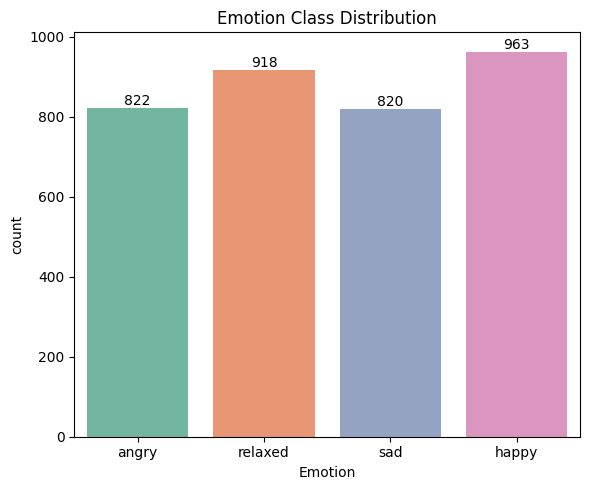

In [ ]:
# Emotion Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns

image = "/content/cleaned_images"

plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x="label", hue="label", palette="Set2")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.0f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center', va='bottom',
        fontsize=10
    )

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")

plt.tight_layout()
plt.show()

###5.4 Compare the emotion label distribution before vs after cleaning


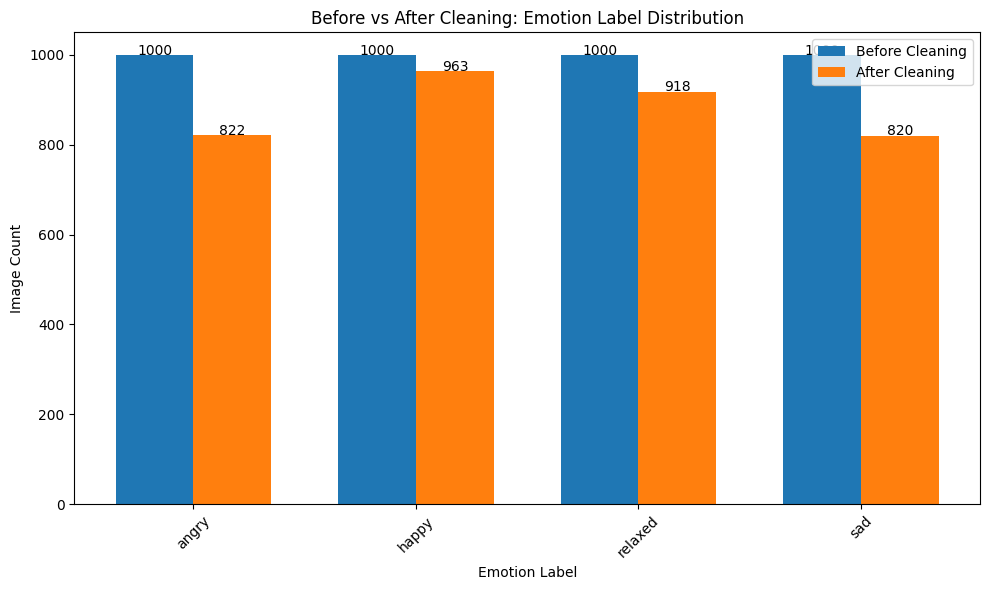

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

raw_df = pd.read_csv("/content/DogEmotion/dog_emotion_labels.csv")
df = pd.read_csv("/content/cleaned_labels.csv")

# Count labels
before_counts = raw_df['label'].value_counts().sort_index()
after_counts = df['label'].value_counts().sort_index()

# Ensure consistent ordering
labels = sorted(list(set(before_counts.index) | set(after_counts.index)))

# Align counts (fill missing classes with zero)
before = [before_counts.get(label, 0) for label in labels]
after = [after_counts.get(label, 0) for label in labels]

# Create grouped bar chart
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, before, width, label='Before Cleaning')
plt.bar(x + width/2, after, width, label='After Cleaning')

plt.xlabel("Emotion Label")
plt.ylabel("Image Count")
plt.title("Before vs After Cleaning: Emotion Label Distribution")
plt.xticks(x, labels, rotation=45)
plt.legend()

# Add numbers above bars
for i, v in enumerate(before):
    plt.text(x[i] - width/2, v + 0.5, str(v), ha='center')

for i, v in enumerate(after):
    plt.text(x[i] + width/2, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


###5.5 Display 9 random sample images with labels


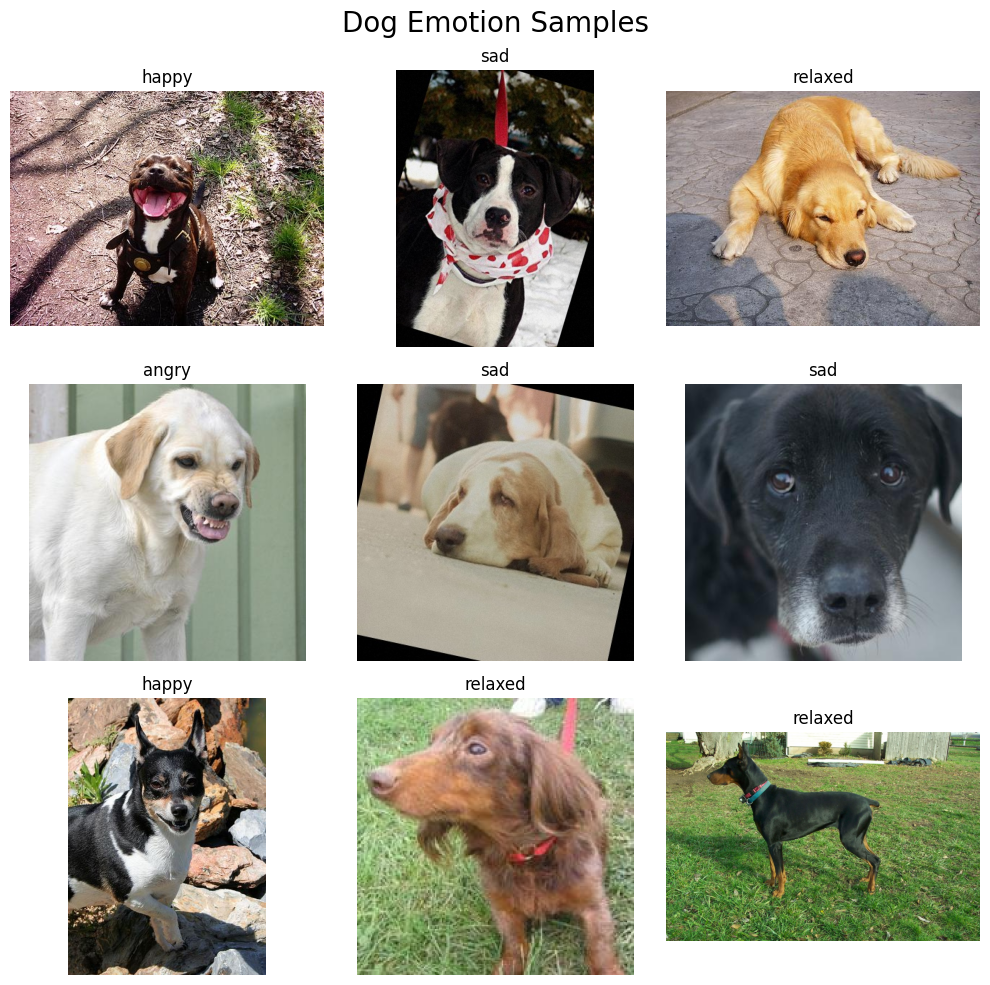

In [ ]:
# Show 9 random sample images with labels
import os
from PIL import Image

sample_df = df.sample(9, random_state=42).reset_index(drop=True)

plt.figure(figsize=(10, 10))

for i in range(9):
    row = sample_df.iloc[i]
    img_path = os.path.join(image, row["filename"])

    img = Image.open(img_path)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.suptitle("Dog Emotion Samples", fontsize=20)
plt.tight_layout()
plt.show()

### 5.6 Pixel Intensity Histogram

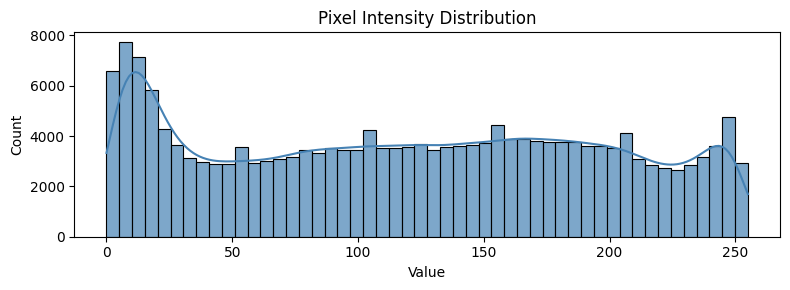

In [ ]:
# Pixel Intensity Histogram (Sample)

import cv2
fixed_row = df.sample(1, random_state=42).iloc[0]
img_path = os.path.join(image, fixed_row['filename'])

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,3))
sns.histplot(gray.flatten(), bins=50, kde=True, color='steelblue', alpha=0.7)
plt.title("Pixel Intensity Distribution")
plt.xlabel('Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

##**6. Data Preprocessing and Augmentation**
Deep learning models require diverse training examples to generalize well.  
Since our dataset contains only around 3,500 unique dog emotion images, we apply **strong data augmentation** to artificially expand the dataset.

The augmentations used include:

- **Random rotation (up to 30°)**  
- **Horizontal flipping**
- **Random zooming (up to 30%)**
- **Width and height shifting**
- **Shearing**
- **Brightness adjustment**
- **Rescaling (1/255)**

These transformations help the model learn *invariance* to lighting, orientation, and position — making the model more robust in real-world situations.

###6.1 Train–Validation–Test Split the Data

We perform a 3-way **stratified split**:

- **70% Training**
- **15% Validation**
- **15% Testing**

Stratification ensures that all sets preserve the original emotion class balance.


In [ ]:
# Splitting the data into training, testing and validation
print("Total images:", len(df))

train_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.1765, stratify=train_df["label"], random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Total images: 3523
Train: 2465
Validation: 529
Test: 529


###6.2 Adding the augmentations to the tranining data

In [ ]:
IMG_SIZE = (224, 224)

# Augmentation for training only
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.7, 1.3]
)

# Validation and test — no augmentation
test_val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Training, validation and testing generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory="/content/cleaned_images",
    x_col="filename",
    y_col="label",
    class_mode="categorical",
    target_size=IMG_SIZE,
    batch_size=32,
    shuffle=True
)

val_generator = test_val_datagen.flow_from_dataframe(
    val_df,
    directory="/content/cleaned_images",
    x_col="filename",
    y_col="label",
    class_mode="categorical",
    target_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

test_generator = test_val_datagen.flow_from_dataframe(
    test_df,
    directory="/content/cleaned_images",
    x_col="filename",
    y_col="label",
    class_mode="categorical",
    target_size=IMG_SIZE,
    batch_size=32,
    shuffle=False
)

Found 2465 validated image filenames belonging to 4 classes.
Found 529 validated image filenames belonging to 4 classes.
Found 529 validated image filenames belonging to 4 classes.


###6.3 Visualising the split distribution of the dataset

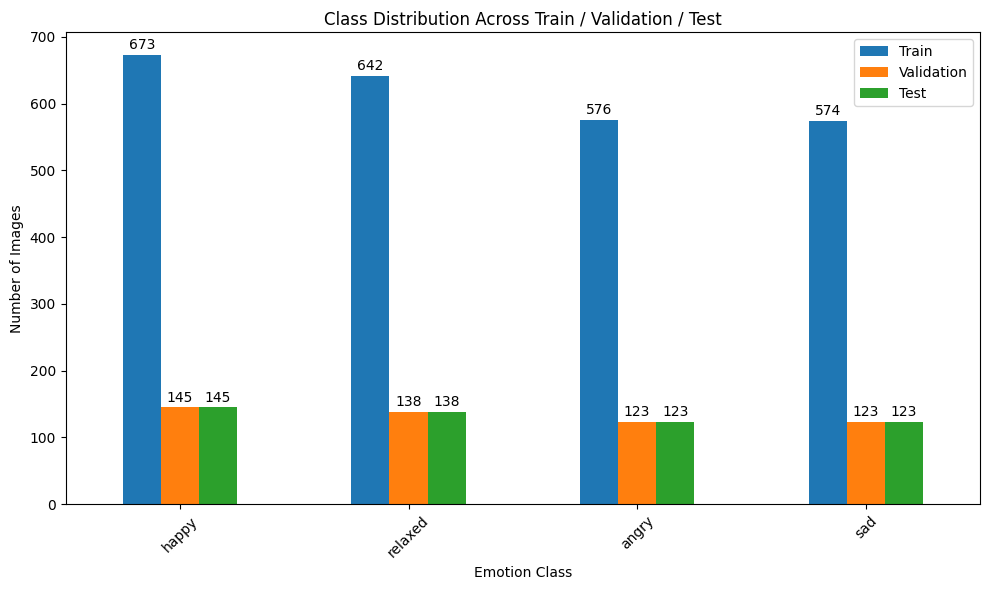

In [ ]:
# Visualising the split distribution accross the dataset
counts = {
    'Train': train_df['label'].value_counts(),
    'Validation': val_df['label'].value_counts(),
    'Test': test_df['label'].value_counts()
}

combined = pd.DataFrame(counts).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10,6))
bars = combined.plot(kind='bar', ax=ax)

plt.title("Class Distribution Across Train / Validation / Test")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2)

plt.tight_layout()
plt.show()


###6.4 Visualising the augmentations for an image

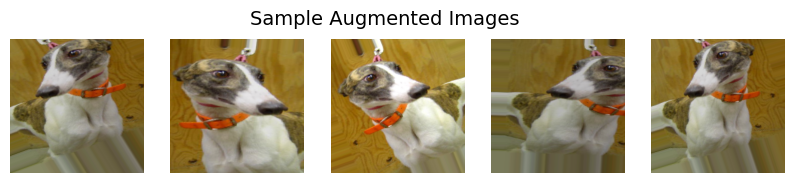

In [ ]:
sample_image_path = "/content/cleaned_images/" + train_df.iloc[2]["filename"]
img = image.load_img(sample_image_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img).reshape((1,) + IMG_SIZE + (3,))

aug_iter = train_datagen.flow(img_array, batch_size=1)

plt.figure(figsize=(10,2))
for i in range(5):
    augmented_img = next(aug_iter)[0]
    plt.subplot(1,5,i+1)
    plt.imshow(augmented_img)
    plt.axis("off")

plt.suptitle("Sample Augmented Images", fontsize=14)
plt.show()

##**7. Model Training**

We use **MobileNetV2**, a lightweight but powerful CNN model pre-trained on ImageNet.

We fine-tune the top layers using our augmented dataset to classify dog emotions.

**Key points:**
- Freeze base layers initially to train only the classification head
- Use **class weights** to handle dataset imbalance
- Apply **early stopping and learning rate reduction** callbacks

###7.1 Handling Imbalanced Classes

Our dataset has uneven numbers of images per emotion.  
To address this, we use **class weights**:

- Assign higher weight to underrepresented classes  
- Assign lower weight to overrepresented classes  
- Ensures model learns all emotions fairly  
- Improves precision and recall for rare emotions


In [ ]:
# Computing class weights
# Get class names
classes = train_df['label'].unique()

# Compute class weights
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)

# Map class names to weights dictionary for Keras
class_weights = dict(zip(classes, class_weights_values))
print("Class weights:", class_weights)

Class weights: {'sad': np.float64(1.0736062717770034), 'relaxed': np.float64(0.9598909657320872), 'happy': np.float64(0.9156760772659732), 'angry': np.float64(1.0698784722222223)}


###7.2 Build Model: Deep Learning Model using Transfer Learning (MobileNetV2)

In [ ]:
# Building a deep learning model using pre-trained CNN model, MobileNetV2
base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

num_classes = len(train_generator.class_indices)  # <-- fixed
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

###7.3 Train model with class weights

In [ ]:
# Training the model with computed class weights
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2465 - loss: 1.5894

78/78 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.2470 - loss: 1.5882 - val_accuracy: 0.3478 - val_loss: 1.3245 - learning_rate: 1.0000e-04
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4016 - loss: 1.2882

78/78 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.4018 - loss: 1.2879 - val_accuracy: 0.4575 - val_loss: 1.2214 - learning_rate: 1.0000e-04
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4955 - loss: 1.1630

78/78 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.4955 - loss: 1.1629 - val_accuracy: 0.5009 - val_loss: 1.1472 - learning_rate: 1.0000e-04
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5211 - loss: 1.1064

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.6606 - loss: 0.8471 - val_accuracy: 0.6200 - val_loss: 0.9305 - learning_rate: 1.0000e-04
Epoch 17/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6669 - loss: 0.8319

78/78 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.6669 - loss: 0.8318 - val_accuracy: 0.6219 - val_loss: 0.9278 - learning_rate: 1.0000e-04
Epoch 18/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6707 - loss: 0.7950

78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.6706 - loss: 0.7952 - val_accuracy: 0.6295 - val_loss: 0.9278 - learning_rate: 1.0000e-04
Epoch 19/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6929 - loss: 0.7833

78/78 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.6928 - loss: 0.7835 - val_accuracy: 0.6125 - val_loss: 0.9042 - learning_rate: 1.0000e-04
Epoch 20/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7034 - loss: 0.7655

78/78 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7033 - loss: 0.7655 - val_accuracy: 0.6371 - val_loss: 0.9014 - learning_rate: 1.0000e-04


###7.4 Fine-Tuning the Model

After training the classification head, we **unfreeze the top 20 layers** of MobileNetV2 to adapt pretrained filters to dog emotion images.  

Class weights continue to be applied during fine-tuning to maintain balanced learning.


In [ ]:
# Unfreeze top 20 layers
for layer in base.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,  # keep class weights during fine-tuning
    callbacks=callbacks
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5769 - loss: 0.9440

78/78 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.5773 - loss: 0.9435 - val_accuracy: 0.6371 - val_loss: 0.8775 - learning_rate: 1.0000e-05
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6544 - loss: 0.8209

78/78 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.6544 - loss: 0.8211 - val_accuracy: 0.6503 - val_loss: 0.8697 - learning_rate: 1.0000e-05
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6601 - loss: 0.8124

78/78 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.6601 - loss: 0.8124 - val_accuracy: 0.6597 - val_loss: 0.8574 - learning_rate: 1.0000e-05
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6905 - loss: 0.7758

78/78 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.6904 - loss: 0.7759 - val_accuracy: 0.6578 - val_loss: 0.8471 - learning_rate: 1.0000e-05
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.6981 - loss: 0.7363 - val_accuracy: 0.6578 - val_loss: 0.8494 - learning_rate: 1.0000e-05
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7011 - loss: 0.7570

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.7409 - loss: 0.6340 - val_accuracy: 0.6975 - val_loss: 0.7658 - learning_rate: 1.0000e-05
Epoch 16/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7551 - loss: 0.6205 - val_accuracy: 0.6975 - val_loss: 0.7699 - learning_rate: 1.0000e-05
Epoch 17/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7773 - loss: 0.5856

78/78 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7773 - loss: 0.5859 - val_accuracy: 0.6994 - val_loss: 0.7606 - learning_rate: 1.0000e-05
Epoch 18/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7671 - loss: 0.6195

78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.7671 - loss: 0.6192 - val_accuracy: 0.7013 - val_loss: 0.7511 - learning_rate: 1.0000e-05
Epoch 19/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7757 - loss: 0.5757

78/78 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7755 - loss: 0.5760 - val_accuracy: 0.6975 - val_loss: 0.7448 - learning_rate: 1.0000e-05
Epoch 20/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7905 - loss: 0.5791

78/78 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.7905 - loss: 0.5790 - val_accuracy: 0.6957 - val_loss: 0.7445 - learning_rate: 1.0000e-05


##**8. Model Evaluation**


###8.1 Evaluating our model, by checking its accuracy

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6835 - loss: 0.7876
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7085 - loss: 0.7674
Validation Accuracy: 0.695652186870575
Test Accuracy: 0.699432909488678


Our deep learning model achieves **~70% accuracy** on training, validation, and test sets, demonstrating robust performance without overfitting. Class weights were applied to improve detection of minority emotions, ensuring fair recognition across all emotion classes.

###8.2 Plot accuracy over epochs

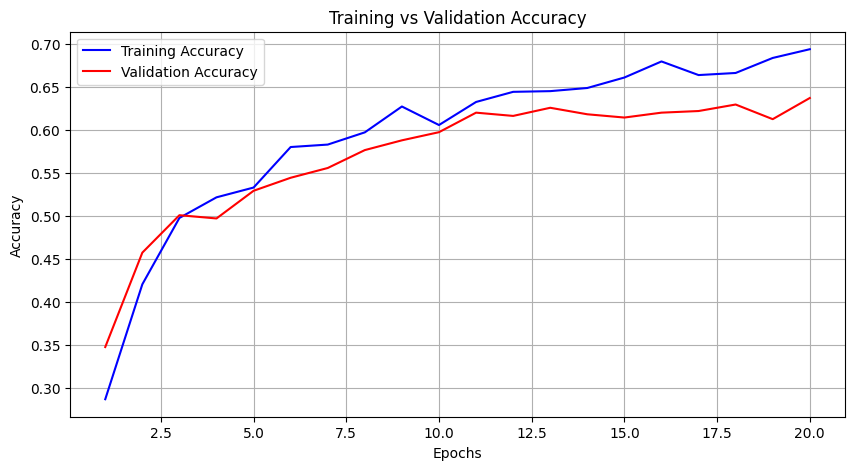

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Accuracy plot
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### 8.3 Confusion Matrix + Classification Report

17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step


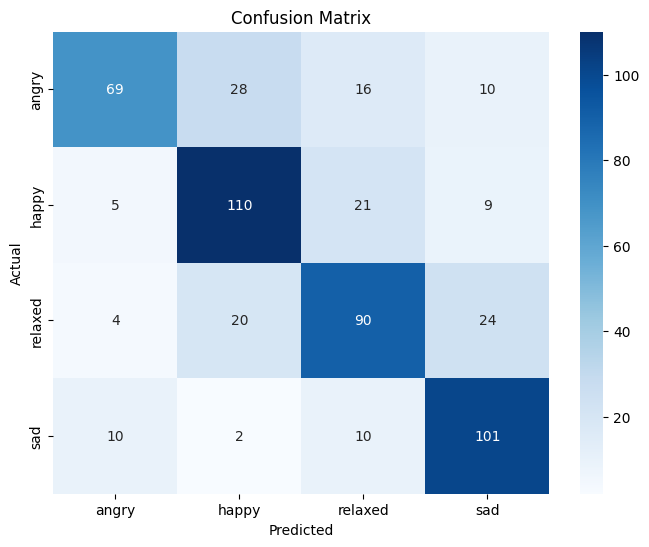

              precision    recall  f1-score   support

       angry       0.78      0.56      0.65       123
       happy       0.69      0.76      0.72       145
     relaxed       0.66      0.65      0.65       138
         sad       0.70      0.82      0.76       123

    accuracy                           0.70       529
   macro avg       0.71      0.70      0.70       529
weighted avg       0.71      0.70      0.70       529



In [ ]:
# True labels
y_true = test_generator.classes

# Predicted labels
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys(),
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=list(test_generator.class_indices.keys())))


Key Findings from Metrics:
* Best Performer (Recall):The **sad** class has the highest recall ($\mathbf{0.82}$), meaning the model is excellent at identifying this emotion when it is truly present.
* Worst Performer (Recall): The **angry** class has the lowest recall ($\mathbf{0.56}$). The model only correctly identifies "angry" about half the time.
* Highest Precision: The **angry** class has the highest precision ($\mathbf{0.78}$). When the model *predicts* "angry," it is correct 78% of the time.
* Lowest F1-Score: Both **angry** and **relaxed** have the lowest F1-score ($\mathbf{0.65}$), indicating these are the most challenging classes for balanced performance.


Conclusion and Improvement Focus

The model's overall performance is 70% accurate. The primary area for improvement is addressing the **low recall for the "angry" class**.

Future efforts should focus on enhancing features or training data to better distinguish **"angry"** from **"happy"** and **"relaxed"** emotions, which are the source of most of its errors.

###8.4 Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


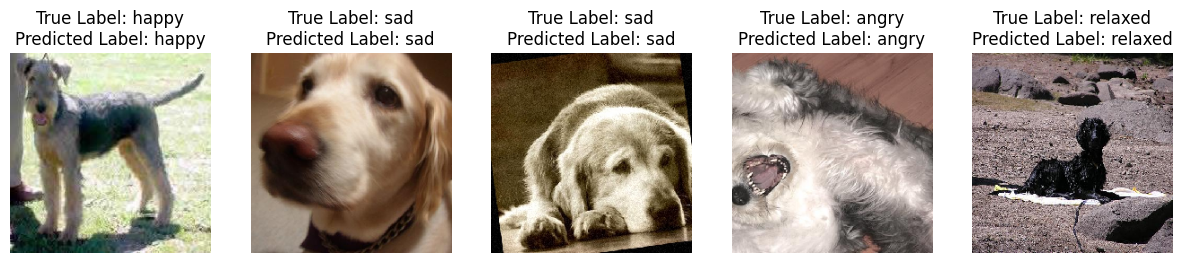

In [ ]:
indices = random.sample(range(len(test_df)), 5)

plt.figure(figsize=(15,8))

for i, idx in enumerate(indices):
    path = "/content/cleaned_images/" + test_df.iloc[idx]["filename"]
    true_label = test_df.iloc[idx]["label"]

    img = load_img(path, target_size=(224,224))
    arr = img_to_array(img)/255.
    pred = model.predict(arr[np.newaxis, ...])
    pred_label = list(test_generator.class_indices.keys())[np.argmax(pred)]

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True Label: {true_label}\nPredicted Label: {pred_label}")

plt.show()

###8.5 Save and export the model

In [ ]:
model.save("dog_emotion_model.h5")

##9 Model Deployment

We deploy our trained model using gradio ui for an easy user interface

In [6]:
MODEL_PATH = '/content/dog_emotion_model.h5'
TARGET_SIZE = (224, 224)
CLASS_NAMES = ['Angry 😡', 'Happy 😀', 'Relaxed 😊', 'Sad ☹️']

if not os.path.exists(MODEL_PATH):
    print(f" Error: Model file not found at '{MODEL_PATH}'")
    sys.exit("Please update MODEL_PATH to the correct location.")

try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"✅ Model '{MODEL_PATH}' loaded successfully.")
except Exception as e:
    print(f" Error loading model: {e}")
    sys.exit("Model loading failed. Check your file format and TensorFlow version.")

def predict_emotion(img):
    if img is None:
        return {"Upload Image": 1.0}, None

    img_pil = Image.fromarray(img).resize(TARGET_SIZE)
    img_array = img_to_array(img_pil) / 255.0 # Normalize

    # Add Batch Dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array)[0]

    # Format results for Gradio Label
    confidences = {CLASS_NAMES[i]: float(preds[i]) for i in range(len(CLASS_NAMES))}

    # Create Plotly figure for visualization
    df = pd.DataFrame({
        'Emotion': CLASS_NAMES,
        'Probability': preds
    }).sort_values(by='Probability', ascending=False)

    # Highlight the highest probability bar
    df['Color'] = np.where(df['Emotion'] == df['Emotion'].iloc[0], '#007BFF', 'lightgrey')

    fig = px.bar(
        df,
        x='Probability',
        y='Emotion',
        orientation='h',
        title='Detailed Probability Score',
        color='Color',
        color_discrete_map='identity',
        text='Probability'
    )
    fig.update_layout(showlegend=False, yaxis={'categoryorder':'total ascending'}, margin={"l": 0, "r": 50, "t": 40, "b": 0})
    fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')

    return confidences, fig

custom_css = """
    .gradio-container {
        font-family: 'Arial', sans-serif;
        background: #f4f7f6;
    }
    h1 {
        color: #0056b3;
        text-align: center;
        font-size: 2.2em;
        margin-bottom: 0.1em;
    }
    .description-text {
        text-align: center;
        color: #666;
        font-size: 1.0em;
        margin-bottom: 25px;
    }
    .panel {
        background: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.05);
    }
"""

with gr.Blocks(css=custom_css, title="Dog Emotion Detector AI") as ui:
    gr.HTML("<h1>🐶 Dog Emotion AI Detector 🐾</h1>")
    gr.HTML("<p class='description-text'>Upload a photo of your dog to analyze its current emotional state using a deep learning model. The output shows the top 3 predictions and a detailed probability graph.</p>")

    with gr.Row():

        with gr.Column(scale=1, min_width=300, elem_classes="panel"):
            input_image = gr.Image(
                type="numpy",
                label="Upload Dog Image",
                height=350,
                sources=["upload", "webcam"]
            )

            # Placeholder for examples (replace paths before deployment)
            gr.Examples(
                examples=[
                    "/content/dogimg1.jpeg",
                    "/content/dogimg2.jpeg",
                ],
                inputs=input_image,
                label="Try these example images",
            )

            predict_btn = gr.Button("Analyze Emotion", variant="primary")

        with gr.Column(scale=2, elem_classes="panel"):
            gr.Markdown("## 🧠 Analysis Results")

            emotion_label = gr.Label(
                num_top_classes=3,
                label="Top Predicted Emotions",
            )

            probability_plot = gr.Plot(label="Probability Visualization")

            gr.Markdown("---")
            gr.Markdown("**Note:** Prediction quality depends on image clarity and quality. Use clear, close-up images.")

    predict_btn.click(
        fn=predict_emotion,
        inputs=[input_image],
        outputs=[emotion_label, probability_plot]
    )

ui.launch()

/tmp/ipython-input-2085670578.py:81: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



✅ Model '/content/dog_emotion_model.h5' loaded successfully.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8747586995b35c982.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
